# MSCS 634 Lab 1: Data Visualization, Preprocessing, and Statistical Analysis

**Name:** Bikram Lamsal  
**Course Title:** MSCS 634 - Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 1 - Data Visualization, Data Preprocessing, and Statistical Analysis  

## Overview
This Jupyter Notebook applies data collection, visualization, preprocessing, and statistical analysis techniques to a product sales dataset. The dataset includes sales revenue, units sold, product categories, regions, customer ratings, and marketing spend.


## 1. Data Collection

For this lab, a product sales dataset is used. The dataset contains product sales records across different regions and dates. It includes numeric fields such as `Units_Sold`, `Unit_Price`, `Customer_Rating`, `Marketing_Spend`, and `Sales_Revenue`, along with categorical fields such as `Product` and `Region`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("product_sales_data.csv")

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Display first five rows
df.head()


,Date,Product,Region,Units_Sold,Unit_Price,Customer_Rating,Marketing_Spend,Sales_Revenue
0,2026-01-02,Phone,West,45,557.86,4.42,1101.11,25103.70
1,2026-01-02,Monitor,West,26,460.62,3.76,834.82,11976.12
2,2026-01-02,Mouse,North,34,495.34,4.56,546.74,16841.56
3,2026-01-02,Monitor,South,32,378.48,3.00,842.70,12111.36
4,2026-01-03,Keyboard,West,34,462.99,4.71,1031.94,15741.66


## 2. Data Visualization

The following visualizations are used to explore trends, relationships, distributions, and category comparisons in the dataset.


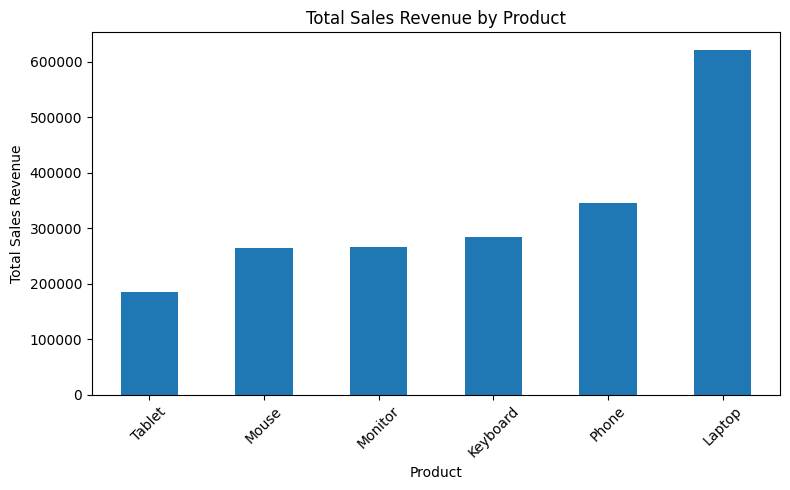

In [2]:
# Bar Chart: Total sales revenue by product
product_sales = df.groupby("Product")["Sales_Revenue"].sum().sort_values()

plt.figure(figsize=(8, 5))
product_sales.plot(kind="bar")
plt.title("Total Sales Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** This bar chart compares total revenue by product. It helps identify which products generated the highest and lowest sales revenue. Products with higher bars are stronger revenue contributors.

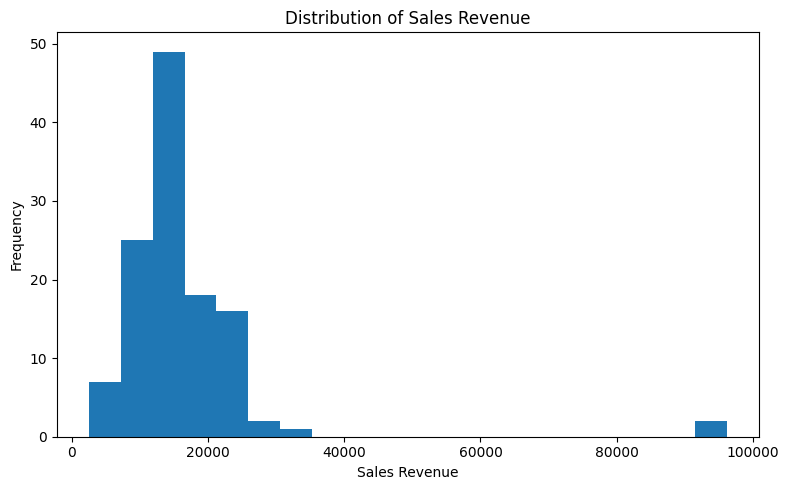

In [3]:
# Histogram: Distribution of Sales Revenue
plt.figure(figsize=(8, 5))
plt.hist(df["Sales_Revenue"].dropna(), bins=20)
plt.title("Distribution of Sales Revenue")
plt.xlabel("Sales Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Insight:** The histogram shows how sales revenue is distributed. Most revenue values fall within a normal operating range, while extremely high values may indicate outliers that need further investigation.

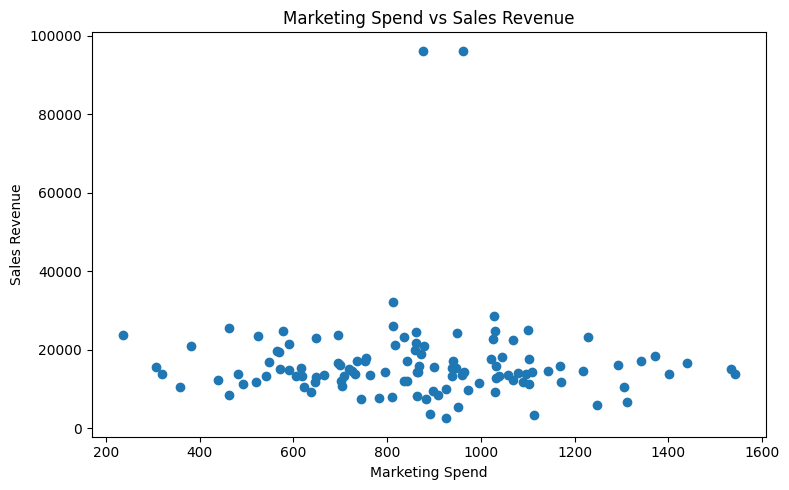

In [4]:
# Scatter Plot: Marketing Spend vs Sales Revenue
plt.figure(figsize=(8, 5))
plt.scatter(df["Marketing_Spend"], df["Sales_Revenue"])
plt.title("Marketing Spend vs Sales Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Sales Revenue")
plt.tight_layout()
plt.show()


**Insight:** This scatter plot shows the relationship between marketing spend and sales revenue. If points trend upward, it may suggest that higher marketing spend is associated with higher revenue.

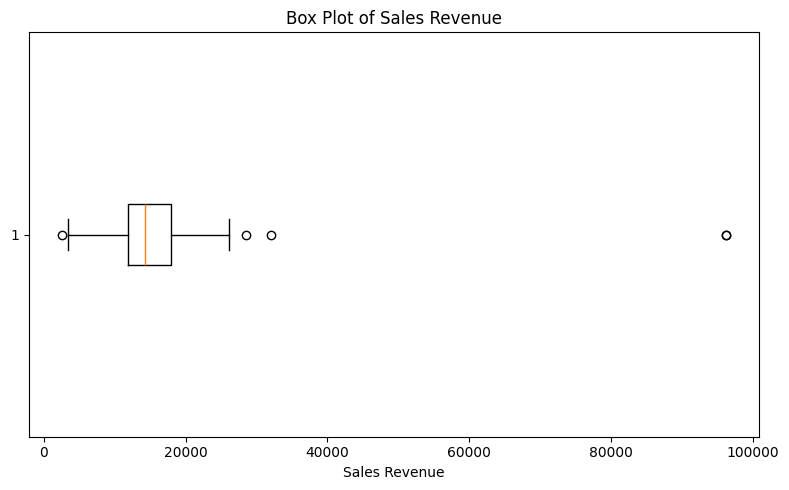

In [5]:
# Box Plot: Sales Revenue
plt.figure(figsize=(8, 5))
plt.boxplot(df["Sales_Revenue"].dropna(), vert=False)
plt.title("Box Plot of Sales Revenue")
plt.xlabel("Sales Revenue")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

This section handles missing values, detects and removes outliers, reduces data size, and applies scaling and discretization.


### 3.1 Handling Missing Values

In [6]:
# Detect missing values before cleaning
missing_before = df.isnull().sum()
missing_before


Date               0
Product            0
Region             0
Units_Sold         0
Unit_Price         4
Customer_Rating    4
Marketing_Spend    4
Sales_Revenue      0
dtype: int64

In [7]:
# Display rows with missing values before handling
df[df.isnull().any(axis=1)].head(10)


,Date,Product,Region,Units_Sold,Unit_Price,Customer_Rating,Marketing_Spend,Sales_Revenue
9,2026-01-06,Laptop,West,32,348.85,4.43,NaN,11163.20
13,2026-01-14,Phone,East,36,NaN,4.43,492.60,11326.68
19,2026-01-18,Laptop,East,26,291.57,4.18,NaN,7580.82
23,2026-01-22,Keyboard,East,32,621.66,NaN,858.87,19893.12
26,2026-01-24,Laptop,South,44,551.89,NaN,949.64,24283.16
37,2026-02-13,Mouse,East,33,NaN,4.37,648.23,13038.30
38,2026-02-13,Keyboard,North,41,545.92,NaN,1068.06,22382.72
39,2026-02-16,Tablet,West,46,123.24,4.04,NaN,5669.04
70,2026-03-13,Laptop,West,40,402.80,4.06,NaN,16112.00
71,2026-03-13,Laptop,West,27,282.04,NaN,782.71,7615.08


In [8]:
# Handle missing values
df_clean = df.copy()

# Fill numeric missing values with the mean
numeric_columns = ["Unit_Price", "Customer_Rating", "Marketing_Spend"]
for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# Recalculate Sales_Revenue if Unit_Price was missing
df_clean["Sales_Revenue"] = (df_clean["Units_Sold"] * df_clean["Unit_Price"]).round(2)

# Confirm missing values after cleaning
missing_after = df_clean.isnull().sum()
missing_after


Date               0
Product            0
Region             0
Units_Sold         0
Unit_Price         0
Customer_Rating    0
Marketing_Spend    0
Sales_Revenue      0
dtype: int64

In [9]:
# Display dataset after handling missing values
df_clean.head(10)


,Date,Product,Region,Units_Sold,Unit_Price,Customer_Rating,Marketing_Spend,Sales_Revenue
0,2026-01-02,Phone,West,45,557.86,4.42,1101.110000,25103.70
1,2026-01-02,Monitor,West,26,460.62,3.76,834.820000,11976.12
2,2026-01-02,Mouse,North,34,495.34,4.56,546.740000,16841.56
3,2026-01-02,Monitor,South,32,378.48,3.00,842.700000,12111.36
4,2026-01-03,Keyboard,West,34,462.99,4.71,1031.940000,15741.66
5,2026-01-03,Laptop,West,32,453.72,4.11,1217.530000,14519.04
6,2026-01-04,Laptop,North,36,379.61,4.18,763.770000,13665.96
7,2026-01-04,Monitor,East,36,232.64,4.47,907.500000,8375.04
8,2026-01-04,Phone,South,36,324.27,4.23,1089.090000,11673.72
9,2026-01-06,Laptop,West,32,348.85,4.43,862.418448,11163.20


### 3.2 Outlier Detection and Removal Using IQR

In [10]:
# IQR calculation for Sales_Revenue
Q1 = df_clean["Sales_Revenue"].quantile(0.25)
Q3 = df_clean["Sales_Revenue"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_results = pd.DataFrame({
    "Metric": ["Q1", "Q3", "IQR", "Lower Bound", "Upper Bound"],
    "Value": [Q1, Q3, IQR, lower_bound, upper_bound]
})

iqr_results


,Metric,Value
0,Q1,11988.00
1,Q3,18197.88
2,IQR,6209.88
3,Lower Bound,2673.18
4,Upper Bound,27512.70


In [11]:
# Identify outliers
outliers = df_clean[(df_clean["Sales_Revenue"] < lower_bound) | (df_clean["Sales_Revenue"] > upper_bound)]
outliers


,Date,Product,Region,Units_Sold,Unit_Price,Customer_Rating,Marketing_Spend,Sales_Revenue
29,2026-02-02,Phone,South,212,451.50,4.13,645.70,95718.00
48,2026-02-22,Keyboard,West,44,728.66,3.91,813.00,32061.04
55,2026-03-01,Monitor,South,212,347.33,4.01,963.19,73633.96
85,2026-03-26,Monitor,North,53,538.37,4.38,1027.57,28533.61
101,2026-04-10,Monitor,West,25,100.62,3.75,925.20,2515.50


In [12]:
# Remove outliers
df_no_outliers = df_clean[(df_clean["Sales_Revenue"] >= lower_bound) & (df_clean["Sales_Revenue"] <= upper_bound)]

print("Original rows:", df_clean.shape[0])
print("Rows after outlier removal:", df_no_outliers.shape[0])

df_no_outliers.head()


Original rows: 120
Rows after outlier removal: 115


,Date,Product,Region,Units_Sold,Unit_Price,Customer_Rating,Marketing_Spend,Sales_Revenue
0,2026-01-02,Phone,West,45,557.86,4.42,1101.11,25103.70
1,2026-01-02,Monitor,West,26,460.62,3.76,834.82,11976.12
2,2026-01-02,Mouse,North,34,495.34,4.56,546.74,16841.56
3,2026-01-02,Monitor,South,32,378.48,3.00,842.70,12111.36
4,2026-01-03,Keyboard,West,34,462.99,4.71,1031.94,15741.66


### 3.3 Data Reduction

In [13]:
# Dataset before data reduction
df_no_outliers.shape, df_no_outliers.head()


((115, 8),
         Date   Product Region  Units_Sold  Unit_Price  Customer_Rating  \
 0 2026-01-02     Phone   West          45      557.86             4.42   
 1 2026-01-02   Monitor   West          26      460.62             3.76   
 2 2026-01-02     Mouse  North          34      495.34             4.56   
 3 2026-01-02   Monitor  South          32      378.48             3.00   
 4 2026-01-03  Keyboard   West          34      462.99             4.71   
 
    Marketing_Spend  Sales_Revenue  
 0          1101.11       25103.70  
 1           834.82       11976.12  
 2           546.74       16841.56  
 3           842.70       12111.36  
 4          1031.94       15741.66  )

In [14]:
# Apply sampling: select 50% of the dataset
df_sampled = df_no_outliers.sample(frac=0.5, random_state=42)

# Dimension elimination: drop less relevant columns
df_reduced = df_sampled.drop(columns=["Customer_Rating"])

print("Shape before reduction:", df_no_outliers.shape)
print("Shape after sampling:", df_sampled.shape)
print("Shape after dropping Customer_Rating:", df_reduced.shape)

df_reduced.head()


Shape before reduction: (115, 8)
Shape after sampling: (58, 8)
Shape after dropping Customer_Rating: (58, 7)


,Date,Product,Region,Units_Sold,Unit_Price,Marketing_Spend,Sales_Revenue
84,2026-03-25,Monitor,East,31,361.93,1103.47,11219.83
4,2026-01-03,Keyboard,West,34,462.99,1031.94,15741.66
41,2026-02-17,Laptop,West,35,395.70,1401.39,13849.50
72,2026-03-14,Phone,North,42,419.19,1021.33,17605.98
10,2026-01-07,Monitor,West,21,383.42,809.53,8051.82


### 3.4 Data Scaling and Discretization

In [15]:
# Dataset before scaling
df_reduced[["Units_Sold", "Unit_Price", "Marketing_Spend", "Sales_Revenue"]].head()


,Units_Sold,Unit_Price,Marketing_Spend,Sales_Revenue
84,31,361.93,1103.47,11219.83
4,34,462.99,1031.94,15741.66
41,35,395.70,1401.39,13849.50
72,42,419.19,1021.33,17605.98
10,21,383.42,809.53,8051.82


In [16]:
# Min-Max Scaling
df_scaled = df_reduced.copy()

columns_to_scale = ["Units_Sold", "Unit_Price", "Marketing_Spend", "Sales_Revenue"]

for col in columns_to_scale:
    df_scaled[col + "_Scaled"] = (
        (df_scaled[col] - df_scaled[col].min()) / 
        (df_scaled[col].max() - df_scaled[col].min())
    )

df_scaled.head()


,Date,Product,Region,Units_Sold,Unit_Price,Marketing_Spend,Sales_Revenue,Units_Sold_Scaled,Unit_Price_Scaled,Marketing_Spend_Scaled,Sales_Revenue_Scaled
84,2026-03-25,Monitor,East,31,361.93,1103.47,11219.83,0.333333,0.333445,0.626427,0.242567
4,2026-01-03,Keyboard,West,34,462.99,1031.94,15741.66,0.433333,0.594084,0.564457,0.489255
41,2026-02-17,Laptop,West,35,395.70,1401.39,13849.50,0.466667,0.420540,0.884532,0.386029
72,2026-03-14,Phone,North,42,419.19,1021.33,17605.98,0.700000,0.481121,0.555265,0.590963
10,2026-01-07,Monitor,West,21,383.42,809.53,8051.82,0.000000,0.388869,0.371771,0.069737


In [17]:
# Discretize Sales_Revenue into categories
df_scaled["Revenue_Category"] = pd.cut(
    df_scaled["Sales_Revenue"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

df_scaled[["Sales_Revenue", "Revenue_Category"]].head(10)


,Sales_Revenue,Revenue_Category
84,11219.83,Low
4,15741.66,Medium
41,13849.50,Medium
72,17605.98,Medium
10,8051.82,Low
46,15292.76,Medium
73,14200.89,Medium
69,6773.53,Low
49,23450.18,High
11,17098.80,Medium


## 4. Statistical Analysis

### 4.1 General Overview of Data

In [18]:
# Dataset information
df_scaled.info()


<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 84 to 25
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    58 non-null     datetime64[ns]
 1   Product                 58 non-null     object        
 2   Region                  58 non-null     object        
 3   Units_Sold              58 non-null     int64         
 4   Unit_Price              58 non-null     float64       
 5   Marketing_Spend         58 non-null     float64       
 6   Sales_Revenue           58 non-null     float64       
 7   Units_Sold_Scaled       58 non-null     float64       
 8   Unit_Price_Scaled       58 non-null     float64       
 9   Marketing_Spend_Scaled  58 non-null     float64       
 10  Sales_Revenue_Scaled    58 non-null     float64       
 11  Revenue_Category        58 non-null     category      
dtypes: category(1), datetime64[ns](1), float64(7), int64(1),

In [19]:
# Descriptive statistics
df_scaled.describe()


,Date,Units_Sold,Unit_Price,Marketing_Spend,Sales_Revenue,Units_Sold_Scaled,Unit_Price_Scaled,Marketing_Spend_Scaled,Sales_Revenue_Scaled
count,58,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,2026-02-24 10:45:31.034482688,35.551724,439.788487,886.316471,15706.862069,0.485057,0.534246,0.438295,0.487357
min,2026-01-02 00:00:00,21.000000,232.640000,380.410000,6773.530000,0.000000,0.000000,0.000000,0.000000
25%,2026-01-24 12:00:00,32.000000,380.310000,702.000000,13317.780000,0.366667,0.380848,0.278611,0.357021
50%,2026-02-21 12:00:00,35.000000,435.960000,869.350000,15152.650000,0.466667,0.524372,0.423596,0.457122
75%,2026-03-24 06:00:00,39.000000,516.985000,1052.272500,18684.222500,0.600000,0.733339,0.582072,0.649786
max,2026-04-26 00:00:00,51.000000,620.380000,1534.670000,25103.700000,1.000000,1.000000,1.000000,1.000000
std,NaN,5.873438,97.941037,243.391702,4612.258184,0.195781,0.252595,0.210864,0.251621


### 4.2 Central Tendency Measures

In [20]:
# Central tendency for selected numeric columns
numeric_df = df_scaled.select_dtypes(include=[np.number])

central_tendency = pd.DataFrame({
    "Minimum": numeric_df.min(),
    "Maximum": numeric_df.max(),
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Mode": numeric_df.mode().iloc[0]
})

central_tendency


,Minimum,Maximum,Mean,Median,Mode
Units_Sold,21.00,51.00,35.551724,35.000000,35.000000
Unit_Price,232.64,620.38,439.788487,435.960000,426.366121
Marketing_Spend,380.41,1534.67,886.316471,869.350000,862.418448
Sales_Revenue,6773.53,25103.70,15706.862069,15152.650000,6773.530000
Units_Sold_Scaled,0.00,1.00,0.485057,0.466667,0.466667
Unit_Price_Scaled,0.00,1.00,0.534246,0.524372,0.499629
Marketing_Spend_Scaled,0.00,1.00,0.438295,0.423596,0.417591
Sales_Revenue_Scaled,0.00,1.00,0.487357,0.457122,0.000000


### 4.3 Dispersion Measures

In [21]:
# Dispersion measures
dispersion = pd.DataFrame({
    "Range": numeric_df.max() - numeric_df.min(),
    "Q1": numeric_df.quantile(0.25),
    "Q3": numeric_df.quantile(0.75),
    "IQR": numeric_df.quantile(0.75) - numeric_df.quantile(0.25),
    "Variance": numeric_df.var(),
    "Standard Deviation": numeric_df.std()
})

dispersion


,Range,Q1,Q3,IQR,Variance,Standard Deviation
Units_Sold,30.00,32.000000,39.000000,7.000000,3.449728e+01,5.873438
Unit_Price,387.74,380.310000,516.985000,136.675000,9.592447e+03,97.941037
Marketing_Spend,1154.26,702.000000,1052.272500,350.272500,5.923952e+04,243.391702
Sales_Revenue,18330.17,13317.780000,18684.222500,5366.442500,2.127293e+07,4612.258184
Units_Sold_Scaled,1.00,0.366667,0.600000,0.233333,3.833031e-02,0.195781
Unit_Price_Scaled,1.00,0.380848,0.733339,0.352491,6.380404e-02,0.252595
Marketing_Spend_Scaled,1.00,0.278611,0.582072,0.303461,4.446356e-02,0.210864
Sales_Revenue_Scaled,1.00,0.357021,0.649786,0.292766,6.331320e-02,0.251621


### 4.4 Correlation Analysis

In [22]:
# Correlation matrix
correlation_matrix = numeric_df.corr()
correlation_matrix


,Units_Sold,Unit_Price,Marketing_Spend,Sales_Revenue,Units_Sold_Scaled,Unit_Price_Scaled,Marketing_Spend_Scaled,Sales_Revenue_Scaled
Units_Sold,1.000000,0.126692,0.024034,0.656068,1.000000,0.126692,0.024034,0.656068
Unit_Price,0.126692,1.000000,-0.201274,0.822059,0.126692,1.000000,-0.201274,0.822059
Marketing_Spend,0.024034,-0.201274,1.000000,-0.140250,0.024034,-0.201274,1.000000,-0.140250
Sales_Revenue,0.656068,0.822059,-0.140250,1.000000,0.656068,0.822059,-0.140250,1.000000
Units_Sold_Scaled,1.000000,0.126692,0.024034,0.656068,1.000000,0.126692,0.024034,0.656068
Unit_Price_Scaled,0.126692,1.000000,-0.201274,0.822059,0.126692,1.000000,-0.201274,0.822059
Marketing_Spend_Scaled,0.024034,-0.201274,1.000000,-0.140250,0.024034,-0.201274,1.000000,-0.140250
Sales_Revenue_Scaled,0.656068,0.822059,-0.140250,1.000000,0.656068,0.822059,-0.140250,1.000000


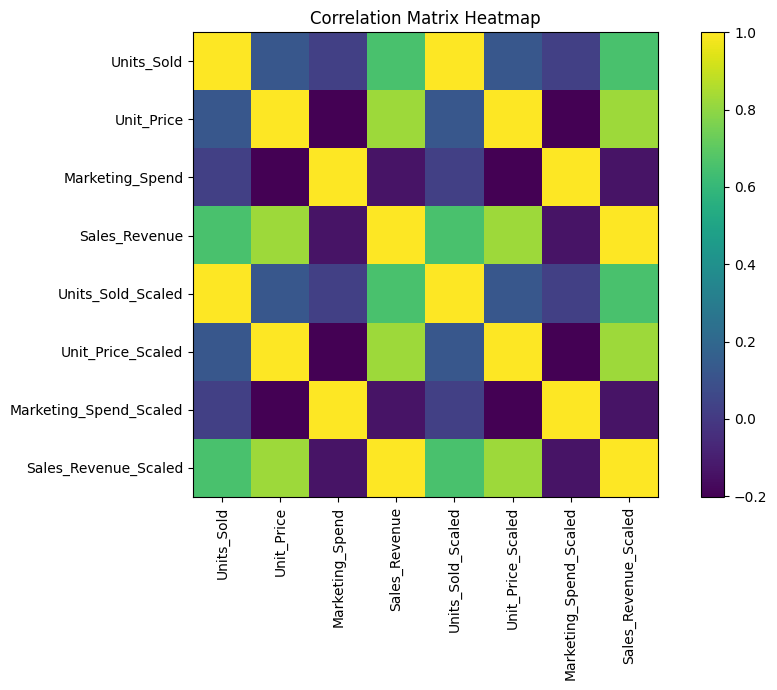

In [23]:
# Optional correlation heatmap using matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()
